# Inspect Japan Conversion

逐步检查原始 Japan 波形与转换后 HDF5/CSV 的一致性，重点查看：

- `record_start_sample`
- `p_picks`
- `pga_norm_*`
- 原始波形插入到对齐波形中的位置


In [1]:
import os
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
sys.path.insert(0, str(Path.cwd()))

from japan_dataset_builder import load_converted_station, load_station_traces_from_event_archive


In [2]:
# 修改成你自己的路径
WAVEFORM_ROOT = Path("/run/media/zhangb/aa0013a6-c6ff-4112-9526-410918058645/Japandata/waveformsnew")
HDF5_PATH = Path("/tmp/japan_build_test3/japan_2000.hdf5")
STATIONS_CSV = Path("/tmp/japan_build_test3/japan_2000_stations.csv")

# 选择方式二选一
ROW_INDEX = 19
EVENT_ID = None
WAVE_IDX = None


In [3]:
def normalize_sensor_suffix(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text


def pick_row(df, row_index=None, event_id=None, wave_idx=None):
    if row_index is not None:
        return df.iloc[row_index]
    if event_id is None:
        return df.iloc[0]
    subset = df[df["EVENT"].astype(str) == str(event_id)]
    if wave_idx is not None:
        subset = subset[subset["wave_idx"] == wave_idx]
    if subset.empty:
        raise ValueError("No matching row found")
    return subset.iloc[0]


def locate_raw_station(row, raw_stations):
    event_id = str(row["EVENT"])
    component_base = str(row["component_base"])
    inner_archive = str(row["inner_archive"])
    sensor_suffix = normalize_sensor_suffix(row["sensor_suffix"])
    for station in raw_stations:
        if (
            station.event_id == event_id
            and station.component_base == component_base
            and station.inner_archive_name == inner_archive
            and station.sensor_suffix == sensor_suffix
        ):
            return station
    raise ValueError("Failed to locate raw station")


In [4]:
stations_df = pd.read_csv(STATIONS_CSV)
print("rows:", len(stations_df))
display(stations_df.head(10))
print("source_network counts:", stations_df["source_network"].value_counts().to_dict())
print("sensor_class counts:", stations_df["sensor_class"].value_counts().to_dict())


rows: 377


,EVENT,wave_idx,Origin_Time(JST),Latitude,Longitude,DEPTH,Magnitude,station_code,station_lat,station_lon,...,stalta_search_left_aligned,stalta_search_right_aligned,stalta_ratio_peak,stalta_ratio_at_pick,stalta_method,stalta_search_feature,stalta_coarse_pick_aligned,p_pick_trigger_aligned,p_pick_refined_aligned,p_pick_refined_source
0,20000101143400,0,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,IWT013,39.3367,141.5378,...,100,200,0.089765,0.089765,stalta_argmax,vertical,100,1600,200,stalta_argmax
1,20000101143400,1,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,MYG003,38.7349,141.3116,...,100,200,0.122887,0.122887,stalta_argmax,vertical,100,1600,200,stalta_argmax
2,20000101143400,2,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,MYG008,38.5769,141.4514,...,0,100,0.159412,0.159412,stalta_argmax,vertical,0,1500,100,stalta_argmax
3,20000101143400,3,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,MYG011,38.2972,141.5043,...,300,400,0.197013,0.197013,stalta_argmax,vertical,300,1800,400,stalta_argmax
4,20000106204000,0,2000/01/06 20:40:00,35.053,135.812,14.0,3.7,HYG010,35.0592,135.1776,...,1861,2361,2.680581,0.244530,stalta_threshold,vertical,2261,3000,1861,stalta_threshold
5,20000106204000,1,2000/01/06 20:40:00,35.053,135.812,14.0,3.7,KYT010,35.2098,135.7738,...,1237,1737,2.748869,0.230745,stalta_threshold,vertical,1637,1900,1537,stalta_threshold
6,20000106204000,2,2000/01/06 20:40:00,35.053,135.812,14.0,3.7,KYT011,35.0171,135.5637,...,1300,1800,2.200301,0.256862,stalta_threshold,vertical,1700,1700,1300,stalta_threshold
7,20000106204000,3,2000/01/06 20:40:00,35.053,135.812,14.0,3.7,KYT012,34.9977,135.8177,...,1109,1609,1.828151,0.252738,stalta_threshold,vertical,1509,1500,1399,stalta_threshold
8,20000106204000,4,2000/01/06 20:40:00,35.053,135.812,14.0,3.7,KYT013,34.8784,135.8046,...,1256,1756,2.179969,0.359979,stalta_threshold,vertical,1656,1900,1256,stalta_threshold
9,20000106204000,5,2000/01/06 20:40:00,35.053,135.812,14.0,3.7,MIE004,34.8568,136.4489,...,1932,2432,1.723778,0.205313,stalta_threshold,vertical,2332,3100,2279,stalta_threshold


source_network counts: {'knt': 225, 'kik': 152}
sensor_class counts: {'single_surface': 225, 'borehole': 76, 'surface': 76}


In [5]:
stations_df[stations_df['source_network']=='knt']

,EVENT,wave_idx,Origin_Time(JST),Latitude,Longitude,DEPTH,Magnitude,station_code,station_lat,station_lon,...,stalta_search_left_aligned,stalta_search_right_aligned,stalta_ratio_peak,stalta_ratio_at_pick,stalta_method,stalta_search_feature,stalta_coarse_pick_aligned,p_pick_trigger_aligned,p_pick_refined_aligned,p_pick_refined_source
0,20000101143400,0,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,IWT013,39.3367,141.5378,...,100,200,0.089765,0.089765,stalta_argmax,vertical,100,1600,200,stalta_argmax
1,20000101143400,1,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,MYG003,38.7349,141.3116,...,100,200,0.122887,0.122887,stalta_argmax,vertical,100,1600,200,stalta_argmax
2,20000101143400,2,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,MYG008,38.5769,141.4514,...,0,100,0.159412,0.159412,stalta_argmax,vertical,0,1500,100,stalta_argmax
3,20000101143400,3,2000/01/01 14:34:00,38.870,142.076,49.0,4.2,MYG011,38.2972,141.5043,...,300,400,0.197013,0.197013,stalta_argmax,vertical,300,1800,400,stalta_argmax
4,20000106204000,0,2000/01/06 20:40:00,35.053,135.812,14.0,3.7,HYG010,35.0592,135.1776,...,1861,2361,2.680581,0.244530,stalta_threshold,vertical,2261,3000,1861,stalta_threshold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,20000112110900,69,2000/01/12 11:09:00,36.453,140.587,58.0,4.4,TCG010,36.6348,139.4379,...,2000,2500,2.034290,0.422083,stalta_threshold,vertical,2400,2400,2000,stalta_threshold
365,20000112110900,70,2000/01/12 11:09:00,36.453,140.587,58.0,4.4,TCG011,36.3869,139.6144,...,1810,2310,1.701815,0.228268,stalta_threshold,vertical,2210,3200,1810,stalta_threshold
366,20000112110900,71,2000/01/12 11:09:00,36.453,140.587,58.0,4.4,TCG012,36.2863,139.8048,...,1624,2124,1.717198,0.383092,stalta_threshold,vertical,2024,2900,1624,stalta_threshold
367,20000112110900,72,2000/01/12 11:09:00,36.453,140.587,58.0,4.4,TCG013,36.4368,140.0227,...,1400,1900,2.238961,0.201053,stalta_threshold,vertical,1800,1800,1400,stalta_threshold


In [6]:
ROW_INDEX = 0
for ROW_INDEX in range(len(stations_df)):
    row = pick_row(stations_df, row_index=ROW_INDEX, event_id=EVENT_ID, wave_idx=WAVE_IDX)
    print(ROW_INDEX, row.stalta_ratio_at_pick)

0 0.0897647953834854
1 0.122887266784155
2 0.1594118711327371
3 0.197012765066966
4 0.2445297080929539
5 0.2307447282394072
6 0.2568617187628232
7 0.2527383606379022
8 0.3599785957015919
9 0.2053130178789418
10 0.22354090479355
11 0.2057552337646484
12 0.207327794627983
13 0.2048884687420386
14 0.2496035801247378
15 0.202298004086278
16 0.3714746988120198
17 0.2408679988557582
18 0.2456672141678601
19 0.2213942904432281
20 0.4983482841684036
21 0.2647697224336512
22 0.3331653210295191
23 0.2114893767514494
24 0.2785389045889543
25 0.2512830138483395
26 0.2644271015651748
27 0.2105038404182651
28 0.2091174968905614
29 0.2230905658123682
30 0.2344935739447448
31 0.2229050497325854
32 0.2046284265586787
33 0.2116578617447134
34 0.2041389459761667
35 0.2087863718930541
36 0.487202195281499
37 0.2354033482859251
38 0.2087093947714968
39 0.203786197014769
40 0.2123490136141233
41 0.2107075024017458
42 0.2087838767633049
43 0.2268955431556111
44 0.2118783819329199
45 0.2063113626514768
46 0.2

In [17]:
ROW_INDEX = 240

In [18]:
row = pick_row(stations_df, row_index=ROW_INDEX, event_id=EVENT_ID, wave_idx=WAVE_IDX)
display(row.to_frame().T)


,EVENT,wave_idx,Origin_Time(JST),Latitude,Longitude,DEPTH,Magnitude,station_code,station_lat,station_lon,...,stalta_search_left_aligned,stalta_search_right_aligned,stalta_ratio_peak,stalta_ratio_at_pick,stalta_method,stalta_search_feature,stalta_coarse_pick_aligned,p_pick_trigger_aligned,p_pick_refined_aligned,p_pick_refined_source
240,20000109224100,0,2000/01/09 22:41:00,36.55,139.364,14.0,3.3,GNMH06,36.2441,139.5443,...,0,100,0.047663,0.047663,stalta_argmax,vertical,0,1500,100,stalta_argmax


In [19]:
archive_path = WAVEFORM_ROOT / row["archive_relpath"]
raw_stations = load_station_traces_from_event_archive(
    outer_tar_path=archive_path,
    archive_relpath=str(row["archive_relpath"]),
    target_sampling_rate_hz=float(row["sampling_rate_hz"]),
)
raw_station = locate_raw_station(row, raw_stations)
converted = load_converted_station(HDF5_PATH, event_id=str(row["EVENT"]), wave_idx=int(row["wave_idx"]))

raw_resampled = raw_station.waveform_resampled
aligned = converted["waveform"]
start_sample = converted["record_start_sample"]
valid_n_samples = converted["valid_n_samples"]
p_pick = converted["p_pick"]
pga_loc = converted["pga_norm_aligned_loc"]

expected = np.zeros_like(aligned)
expected[start_sample:start_sample + raw_resampled.shape[0], :] = raw_resampled

inserted = aligned[start_sample:start_sample + valid_n_samples]
checks = {
    "record_start_sample_csv": int(row["record_start_sample"]),
    "record_start_sample_hdf5": int(start_sample),
    "valid_n_samples_csv": int(row["valid_n_samples"]),
    "valid_n_samples_hdf5": int(valid_n_samples),
    "p_pick_aligned_csv": int(row["p_pick_refined_aligned"]),
    "p_pick_hdf5": int(p_pick),
    "pga_norm_resampled_mps2_csv": float(row["pga_norm_resampled_mps2"]),
    "pga_norm_resampled_mps2_hdf5": float(converted["pga_norm_resampled_mps2"]),
    "pga_norm_resampled_mps2_raw": float(raw_station.pga_norm_resampled_mps2),
    "pga_norm_native_mps2_csv": float(row["pga_norm_native_mps2"]),
    "pga_norm_native_mps2_hdf5": float(converted["pga_norm_native_mps2"]),
    "pga_norm_native_mps2_raw": float(raw_station.pga_norm_native_mps2),
    "pga_norm_aligned_loc_csv": int(row["pga_norm_aligned_loc"]),
    "pga_norm_aligned_loc_hdf5": int(pga_loc),
    "inserted_max_abs_diff": float(np.max(np.abs(inserted - raw_resampled))),
    "inserted_rms_diff": float(np.sqrt(np.mean((inserted - raw_resampled) ** 2))),
    "full_max_abs_diff": float(np.max(np.abs(aligned - expected))),
}
display(pd.Series(checks))

print("max_acc_header raw:", raw_station.max_acc_header_gal)
print("max_acc_header hdf5:", converted["max_acc_header_gal"])
print("raw sampling rate:", raw_station.sampling_rate_raw_hz)
print("target sampling rate:", raw_station.sampling_rate_target_hz)
print("record_time_raw:", raw_station.record_time_raw)
print("record_start_time_jst:", row["record_start_time_jst"])
print("trigger_time_jst:", row["trigger_time_jst"])


record_start_sample_csv            0.000000
record_start_sample_hdf5           0.000000
valid_n_samples_csv             6000.000000
valid_n_samples_hdf5            6000.000000
p_pick_aligned_csv               100.000000
p_pick_hdf5                      100.000000
pga_norm_resampled_mps2_csv        0.011097
pga_norm_resampled_mps2_hdf5       0.011097
pga_norm_resampled_mps2_raw        0.011097
pga_norm_native_mps2_csv           0.012645
pga_norm_native_mps2_hdf5          0.012645
pga_norm_native_mps2_raw           0.012645
pga_norm_aligned_loc_csv        1477.000000
pga_norm_aligned_loc_hdf5       1477.000000
inserted_max_abs_diff              0.000000
inserted_rms_diff                  0.000000
full_max_abs_diff                  0.000000
dtype: float64

max_acc_header raw: [0.789 1.207 0.821]
max_acc_header hdf5: [0.789 1.207 0.821]
raw sampling rate: 200.0
target sampling rate: 100.0
record_time_raw: 2000/01/09 22:41:37
record_start_time_jst: 2000-01-09T22:41:22+09:00
trigger_time_jst: 2000-01-09T22:41:37+09:00


In [20]:
for key,val in row.items():
    print(key, val)

EVENT 20000109224100
wave_idx 0
Origin_Time(JST) 2000/01/09 22:41:00
Latitude 36.55
Longitude 139.364
DEPTH 14.0
Magnitude 3.3
station_code GNMH06
station_lat 36.2441
station_lon 139.5443
station_height_m -1183.0
source_network kik
sensor_class borehole
sensor_suffix 1.0
raw_dir_ns 1
raw_dir_ew 2
raw_dir_ud 3
scale_factor_ns 2000(gal)/8388608
scale_factor_ew 2000(gal)/8388608
scale_factor_ud 2000(gal)/8388608
sampling_rate_raw_hz 200.0
sampling_rate_hz 100.0
duration_header_s 60.0
raw_n_samples 12000
resampled_n_samples 6000
record_time_raw 2000/01/09 22:41:37
record_time_jst 2000-01-09T22:41:37+09:00
record_start_time_jst 2000-01-09T22:41:22+09:00
trigger_time_jst 2000-01-09T22:41:37+09:00
record_start_sample 0
valid_n_samples 6000
p_pick_raw 3000
p_pick_resampled 1500
p_pick_aligned 100
pga_norm_native_mps2 0.0126450902226012
pga_norm_resampled_mps2 0.0110968817206848
pga_norm_native_loc_raw 2953
pga_norm_resampled_loc 1477
pga_norm_aligned_loc 1477
pga_vector_native_ns_mps2 0.007889

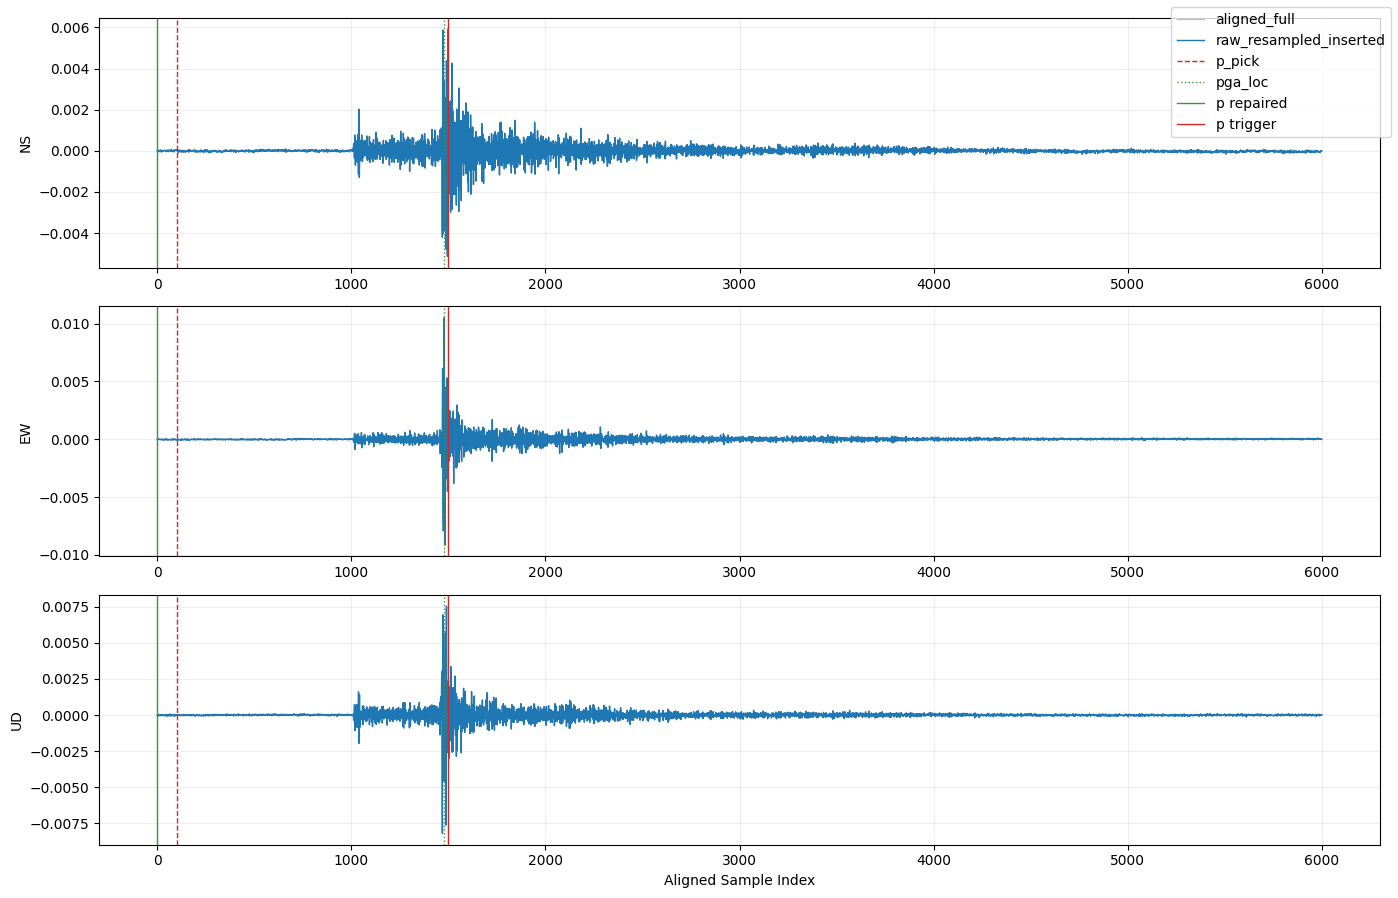

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
labels = ["NS", "EW", "UD"]
x_raw = np.arange(raw_resampled.shape[0])
x_aligned = np.arange(aligned.shape[0])

for i, ax in enumerate(axes):
    ax.plot(x_aligned, aligned[:, i], color="0.75", linewidth=0.9, label="aligned_full")
    ax.plot(start_sample + x_raw, raw_resampled[:, i], color="C0", linewidth=1.0, label="raw_resampled_inserted")
    ax.axvline(p_pick, color="C3", linestyle="--", linewidth=1.0, label="p_pick" if i == 0 else None)
    ax.axvline(pga_loc, color="C2", linestyle=":", linewidth=1.0, label="pga_loc" if i == 0 else None)
    ax.axvline(row.p_pick_repaired_aligned, color="C2", linestyle="-", linewidth=1.0, label="p repaired" if i == 0 else None)
    ax.axvline(row.p_pick_trigger_aligned, color="C3", linestyle="-", linewidth=1.0, label="p trigger" if i == 0 else None)
    ax.set_ylabel(labels[i])
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Aligned Sample Index")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right")
fig.tight_layout()
plt.show()
plt.close('all')

In [17]:
import japan_dataset_builder as jdb
# import importlib
# importlib.reload(jdb)
ref_res = jdb.refine_pick_stalta(waveform_aligned=aligned, coarse_pick_aligned=row.p_pick_repaired_aligned, sampling_rate_hz=100,
                  record_start_sample=row.record_start_sample, valid_n_samples=row.valid_n_samples,
                  pre_seconds=4., post_seconds=1., sta_seconds=0.2, lta_seconds=1.0, threshold_ratio=0.2)

In [18]:
sta_n = max(1, int(round(0.2 * 100)))
lta_n = max(sta_n + 1, int(round(1.0 * 100)))
print(sta_n, lta_n)

20 100


In [19]:
ddd = np.abs(aligned[(row.p_pick_repaired_aligned-400):(row.p_pick_repaired_aligned+100), 2])
sta = jdb._moving_average_same(ddd, sta_n)
lta = jdb._moving_average_same(ddd, lta_n)
ratio = sta / np.maximum(lta, 5e-4)

ValueError: v cannot be empty

In [ ]:
plt.plot(ratio)
plt.show()
plt.close('all')

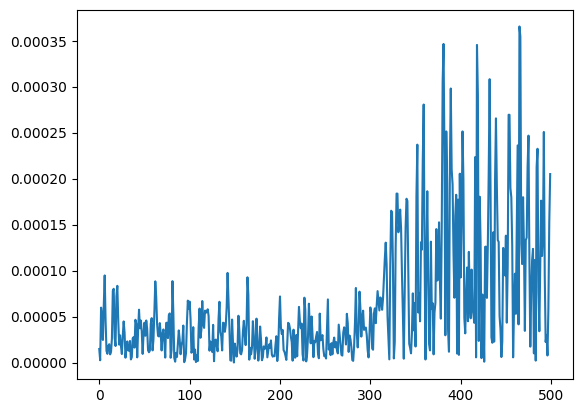

In [25]:
plt.plot(np.abs(aligned[(row.p_pick_repaired_aligned-400):(row.p_pick_repaired_aligned+100), 2]))
plt.show()
plt.close('all')

In [99]:
ref_res

{'refined_pick_aligned': 1972,
 'search_left_aligned': 1900,
 'search_right_aligned': 2400,
 'ratio_peak': 1.5922438102732295,
 'ratio_at_pick': 1.5922438102732295,
 'method': 'stalta_argmax',
 'search_feature': 'vertical',
 'coarse_pick_aligned': 2300}

In [26]:
# 检查当前事件内所有台站的时间信息
event_df = stations_df[stations_df["EVENT"].astype(str) == str(row["EVENT"])].copy()
cols = [
    "wave_idx",
    "station_code",
    "source_network",
    "sensor_class",
    "sampling_rate_raw_hz",
    "record_start_sample",
    "valid_n_samples",
    "p_pick_aligned",
    "pga_norm_aligned_loc",
    "record_time_raw",
    "record_start_time_jst",
    "trigger_time_jst",
]
display(event_df[cols].sort_values(["record_start_sample", "p_pick_aligned", "wave_idx"]))


,wave_idx,station_code,source_network,sensor_class,sampling_rate_raw_hz,record_start_sample,valid_n_samples,p_pick_aligned,pga_norm_aligned_loc,record_time_raw,record_start_time_jst,trigger_time_jst
7,3,KYT012,knt,single_surface,100.0,0,11900,1436,1607,2000/01/06 20:40:07,2000-01-06T20:39:52+09:00,2000-01-06T20:40:07+09:00
20,16,SIG010,knt,single_surface,100.0,0,11900,1498,1738,2000/01/06 20:40:07,2000-01-06T20:39:52+09:00,2000-01-06T20:40:07+09:00
6,2,KYT011,knt,single_surface,100.0,200,11900,1661,2005,2000/01/06 20:40:09,2000-01-06T20:39:54+09:00,2000-01-06T20:40:09+09:00
75,71,SIGH03,kik,borehole,200.0,300,6000,1763,2138,2000/01/06 20:40:10,2000-01-06T20:39:55+09:00,2000-01-06T20:40:10+09:00
76,72,SIGH03,kik,surface,200.0,300,6000,1775,2249,2000/01/06 20:40:10,2000-01-06T20:39:55+09:00,2000-01-06T20:40:10+09:00
...,...,...,...,...,...,...,...,...,...,...,...,...
47,43,HYGH12,kik,borehole,200.0,3100,6000,3339,4549,2000/01/06 20:40:38,2000-01-06T20:40:23+09:00,2000-01-06T20:40:38+09:00
35,31,HYGH05,kik,borehole,200.0,3600,6000,3700,5067,2000/01/06 20:40:43,2000-01-06T20:40:28+09:00,2000-01-06T20:40:43+09:00
36,32,HYGH05,kik,surface,200.0,3600,6000,3700,5118,2000/01/06 20:40:43,2000-01-06T20:40:28+09:00,2000-01-06T20:40:43+09:00
63,59,OKYH12,kik,borehole,200.0,3600,6000,3700,5075,2000/01/06 20:40:43,2000-01-06T20:40:28+09:00,2000-01-06T20:40:43+09:00
